# RxGuide AI — Data Cleaning and Exploratory Analysis

This notebook validates, cleans, and explores the pharmaceutical commercial datasets used for HCP targeting and sales-force effectiveness analysis.

## Objectives

- Load and inspect all six datasets
- Validate columns, datatypes, and identifiers
- Detect missing values and duplicate records
- Verify relationships between datasets
- Perform focused exploratory analysis
- Export cleaned datasets for SQL and machine learning

In [1]:
import sys
print(sys.executable)

d:\rxguide\rxguide-hcp-analytics\venv\Scripts\python.exe


In [2]:
import sys
!{sys.executable} -m pip install matplotlib

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
    # Detect the project root regardless of whether the notebook
# runs from the repository root or the notebooks folder.

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")

Project root: d:\rxguide\rxguide-hcp-analytics
Raw data directory: d:\rxguide\rxguide-hcp-analytics\data\raw
Processed data directory: d:\rxguide\rxguide-hcp-analytics\data\processed


In [5]:
file_paths = {
    "hcps": RAW_DATA_DIR / "hcps.csv",
    "sales_reps": RAW_DATA_DIR / "sales_reps.csv",
    "products": RAW_DATA_DIR / "products.csv",
    "call_activity": RAW_DATA_DIR / "call_activity.csv",
    "prescriptions": RAW_DATA_DIR / "prescriptions.csv",
    "ic_quotas": RAW_DATA_DIR / "ic_quotas.csv",
}

missing_files = [
    str(path)
    for path in file_paths.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following dataset files were not found:\n"
        + "\n".join(missing_files)
    )

datasets = {
    name: pd.read_csv(path)
    for name, path in file_paths.items()
}

print("All datasets loaded successfully.\n")

for name, dataframe in datasets.items():
    print(f"{name:<15} -> {dataframe.shape[0]:>6,} rows × "
          f"{dataframe.shape[1]:>2} columns")

All datasets loaded successfully.

hcps            ->    500 rows ×  7 columns
sales_reps      ->     50 rows ×  7 columns
products        ->      5 rows ×  5 columns
call_activity   -> 13,705 rows ×  8 columns
prescriptions   -> 17,329 rows ×  6 columns
ic_quotas       ->    200 rows ×  6 columns


In [6]:
dataset_overview = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": dataframe.shape[0],
            "columns": dataframe.shape[1],
            "missing_values": int(dataframe.isna().sum().sum()),
            "duplicate_rows": int(dataframe.duplicated().sum()),
            "memory_mb": dataframe.memory_usage(deep=True).sum() / (1024 ** 2),
        }
        for name, dataframe in datasets.items()
    ]
)

dataset_overview["memory_mb"] = dataset_overview["memory_mb"].round(3)

dataset_overview

,dataset,rows,columns,missing_values,duplicate_rows,memory_mb
0,hcps,500,7,0,0,0.19
1,sales_reps,50,7,0,0,0.02
2,products,5,5,0,0,0.00
3,call_activity,13705,8,0,0,4.50
4,prescriptions,17329,6,0,0,3.97
5,ic_quotas,200,6,0,0,0.03


In [7]:
for name, dataframe in datasets.items():
    print("=" * 90)
    print(name.upper())
    print("=" * 90)

    print("\nColumns:")
    print(dataframe.columns.tolist())

    print("\nSample records:")
    display(dataframe.head(3))

    print()

HCPS

Columns:
['hcp_id', 'hcp_name', 'specialty', 'territory', 'region', 'segment', 'city']

Sample records:


,hcp_id,hcp_name,specialty,territory,region,segment,city
0,H0001,Dr. HCP_0001,Endocrinologist,North-1,North,B,Delhi
1,H0002,Dr. HCP_0002,Pulmonologist,North-1,North,C,Delhi
2,H0003,Dr. HCP_0003,Endocrinologist,Central-1,Central,C,Chennai



SALES_REPS

Columns:
['rep_id', 'rep_name', 'territory', 'region', 'manager', 'tenure_months', 'hire_date']

Sample records:


,rep_id,rep_name,territory,region,manager,tenure_months,hire_date
0,R001,Rep_001,North-2,North,Rajesh Kumar,38,2021-01-03
1,R002,Rep_002,South-2,South,Priya Sharma,16,2017-08-22
2,R003,Rep_003,North-2,North,Vikram Singh,57,2023-05-26



PRODUCTS

Columns:
['product_id', 'product_name', 'therapy_area', 'launch_year', 'unit_price']

Sample records:


...

,call_id,rep_id,hcp_id,product_id,call_date,call_type,duration_min,samples_given
0,C000001,R001,H0185,P002,2026-04-08,F2F,21,5
1,C000002,R001,H0410,P003,2026-01-25,F2F,17,7
2,C000003,R001,H0300,P003,2025-11-15,F2F,13,0



PRESCRIPTIONS

Columns:
['rx_id', 'hcp_id', 'product_id', 'rx_month', 'rx_count', 'units_dispensed']

Sample records:


,rx_id,hcp_id,product_id,rx_month,rx_count,units_dispensed
0,RX0000001,H0001,P001,2025-05-01,2,98
1,RX0000002,H0001,P001,2025-05-01,2,104
2,RX0000003,H0001,P001,2025-06-01,1,49



IC_QUOTAS

Columns:
['rep_id', 'quarter', 'quota_units', 'actual_units', 'attainment_pct', 'payout_inr']

Sample records:


,rep_id,quarter,quota_units,actual_units,attainment_pct,payout_inr
0,R001,2025-Q2,1719,1555,90.50,67844
1,R001,2025-Q3,1634,1857,113.60,85235
2,R001,2025-Q4,1134,1334,117.60,88227


## Detailed Data Profiling

In this section, each dataset is examined for datatypes, missing values, unique values, numerical distributions, and categorical consistency before any cleaning decisions are made.

In [8]:
# Create readable variable names for individual datasets

hcps = datasets["hcps"].copy()
sales_reps = datasets["sales_reps"].copy()
products = datasets["products"].copy()
calls = datasets["call_activity"].copy()
prescriptions = datasets["prescriptions"].copy()
quotas = datasets["ic_quotas"].copy()

print("Individual DataFrames created successfully.")

Individual DataFrames created successfully.


In [9]:
dataframes = {
    "HCPs": hcps,
    "Sales Representatives": sales_reps,
    "Products": products,
    "Call Activity": calls,
    "Prescriptions": prescriptions,
    "IC Quotas": quotas,
}

for name, dataframe in dataframes.items():
    print(f"\n{name}")
    print("-" * len(name))

    for column_number, column_name in enumerate(
        dataframe.columns,
        start=1
    ):
        print(f"{column_number:>2}. {column_name}")


HCPs
----
 1. hcp_id
 2. hcp_name
 3. specialty
 4. territory
 5. region
 6. segment
 7. city

Sales Representatives
---------------------
 1. rep_id
 2. rep_name
 3. territory
 4. region
 5. manager
 6. tenure_months
 7. hire_date

Products
--------
 1. product_id
 2. product_name
 3. therapy_area
 4. launch_year
 5. unit_price

Call Activity
-------------
 1. call_id
 2. rep_id
 3. hcp_id
 4. product_id
 5. call_date
 6. call_type
 7. duration_min
 8. samples_given

Prescriptions
-------------
 1. rx_id
 2. hcp_id
 3. product_id
 4. rx_month
 5. rx_count
 6. units_dispensed

IC Quotas
---------
 1. rep_id
 2. quarter
 3. quota_units
 4. actual_units
 5. attainment_pct
 6. payout_inr


In [10]:
for name, dataframe in dataframes.items():
    print("\n" + "=" * 100)
    print(name.upper())
    print("=" * 100)

    dataframe.info()


HCPS
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   hcp_id     500 non-null    str  
 1   hcp_name   500 non-null    str  
 2   specialty  500 non-null    str  
 3   territory  500 non-null    str  
 4   region     500 non-null    str  
 5   segment    500 non-null    str  
 6   city       500 non-null    str  
dtypes: str(7)
memory usage: 27.5 KB

SALES REPRESENTATIVES
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   rep_id         50 non-null     str  
 1   rep_name       50 non-null     str  
 2   territory      50 non-null     str  
 3   region         50 non-null     str  
 4   manager        50 non-null     str  
 5   tenure_months  50 non-null     int64
 6   hire_date      50 non-null     str  
dtypes: int64(1), str(6)
memor

In [11]:
def create_column_profile(dataframe):
    """
    Create a column-level data-quality summary for a DataFrame.
    """

    profile_rows = []

    for column in dataframe.columns:
        series = dataframe[column]

        non_null_series = series.dropna()

        sample_values = (
            non_null_series
            .astype(str)
            .drop_duplicates()
            .head(3)
            .tolist()
        )

        profile_rows.append(
            {
                "column": column,
                "datatype": str(series.dtype),
                "total_rows": len(series),
                "missing_values": int(series.isna().sum()),
                "missing_percentage": round(
                    series.isna().mean() * 100,
                    2
                ),
                "unique_values": int(series.nunique(dropna=True)),
                "sample_values": ", ".join(sample_values),
            }
        )

    return pd.DataFrame(profile_rows)

In [12]:
column_profiles = {}

for name, dataframe in dataframes.items():
    profile = create_column_profile(dataframe)
    column_profiles[name] = profile

    print("\n" + "=" * 100)
    print(f"{name.upper()} — COLUMN PROFILE")
    print("=" * 100)

    display(profile)


HCPS — COLUMN PROFILE


,column,datatype,total_rows,missing_values,missing_percentage,unique_values,sample_values
0,hcp_id,str,500,0,0.00,500,"H0001, H0002, H0003"
1,hcp_name,str,500,0,0.00,500,"Dr. HCP_0001, Dr. HCP_0002, Dr. HCP_0003"
2,specialty,str,500,0,0.00,6,"Endocrinologist, Pulmonologist, Neurologist"
3,territory,str,500,0,0.00,10,"North-1, Central-1, West-2"
4,region,str,500,0,0.00,5,"North, Central, West"
5,segment,str,500,0,0.00,3,"B, C, A"
6,city,str,500,0,0.00,8,"Delhi, Chennai, Bangalore"



SALES REPRESENTATIVES — COLUMN PROFILE


,column,datatype,total_rows,missing_values,missing_percentage,unique_values,sample_values
0,rep_id,str,50,0,0.00,50,"R001, R002, R003"
1,rep_name,str,50,0,0.00,50,"Rep_001, Rep_002, Rep_003"
2,territory,str,50,0,0.00,9,"North-2, South-2, North-1"
3,region,str,50,0,0.00,5,"North, South, Central"
4,manager,str,50,0,0.00,5,"Rajesh Kumar, Priya Sharma, Vikram Singh"
5,tenure_months,int64,50,0,0.00,37,"38, 16, 57"
6,hire_date,str,50,0,0.00,49,"2021-01-03, 2017-08-22, 2023-05-26"



PRODUCTS — COLUMN PROFILE


...

,column,datatype,total_rows,missing_values,missing_percentage,unique_values,sample_values
0,call_id,str,13705,0,0.00,13705,"C000001, C000002, C000003"
1,rep_id,str,13705,0,0.00,50,"R001, R002, R003"
2,hcp_id,str,13705,0,0.00,444,"H0185, H0410, H0300"
3,product_id,str,13705,0,0.00,5,"P002, P003, P001"
4,call_date,str,13705,0,0.00,365,"2026-04-08, 2026-01-25, 2025-11-15"
5,call_type,str,13705,0,0.00,2,"F2F, Virtual"
6,duration_min,int64,13705,0,0.00,31,"21, 17, 13"
7,samples_given,int64,13705,0,0.00,9,"5, 7, 0"



PRESCRIPTIONS — COLUMN PROFILE


,column,datatype,total_rows,missing_values,missing_percentage,unique_values,sample_values
0,rx_id,str,17329,0,0.00,17329,"RX0000001, RX0000002, RX0000003"
1,hcp_id,str,17329,0,0.00,485,"H0001, H0002, H0003"
2,product_id,str,17329,0,0.00,5,"P001, P002, P003"
3,rx_month,str,17329,0,0.00,11,"2025-05-01, 2025-06-01, 2025-08-01"
4,rx_count,int64,17329,0,0.00,17,"2, 1, 6"
5,units_dispensed,int64,17329,0,0.00,314,"98, 104, 49"



IC QUOTAS — COLUMN PROFILE


,column,datatype,total_rows,missing_values,missing_percentage,unique_values,sample_values
0,rep_id,str,200,0,0.00,50,"R001, R002, R003"
1,quarter,str,200,0,0.00,4,"2025-Q2, 2025-Q3, 2025-Q4"
2,quota_units,int64,200,0,0.00,181,"1719, 1634, 1134"
3,actual_units,int64,200,0,0.00,189,"1555, 1857, 1334"
4,attainment_pct,float64,200,0,0.00,174,"90.5, 113.6, 117.6"
5,payout_inr,int64,200,0,0.00,200,"67844, 85235, 88227"


## Numerical and Categorical Distributions

In [13]:
for name, dataframe in dataframes.items():
    numeric_columns = dataframe.select_dtypes(
        include=np.number
    ).columns.tolist()

    print("\n" + "=" * 100)
    print(f"{name.upper()} — NUMERICAL SUMMARY")
    print("=" * 100)

    if numeric_columns:
        display(
            dataframe[numeric_columns]
            .describe()
            .T
            .round(2)
        )
    else:
        print("No numerical columns found.")


HCPS — NUMERICAL SUMMARY
No numerical columns found.

SALES REPRESENTATIVES — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
tenure_months,50.00,40.30,22.19,3.00,19.25,38.00,55.50,84.00



PRODUCTS — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
launch_year,5.00,"2,021.00",1.58,"2,019.00","2,020.00","2,021.00","2,022.00","2,023.00"
unit_price,5.00,954.00,"1,035.75",380.00,450.00,520.00,620.00,"2,800.00"



CALL ACTIVITY — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
duration_min,"13,705.00",19.98,8.95,5.00,12.00,20.00,28.00,35.00
samples_given,"13,705.00",3.98,2.59,0.00,2.00,4.00,6.00,8.00



PRESCRIPTIONS — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
rx_count,"17,329.00",2.49,1.89,1.00,1.00,2.00,3.00,17.00
units_dispensed,"17,329.00",99.53,84.26,20.00,44.00,70.00,125.00,896.00



IC QUOTAS — NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
quota_units,200.00,"1,501.94",386.43,821.00,"1,186.75","1,474.50","1,799.75","2,194.00"
actual_units,200.00,"1,439.86",505.06,568.00,"1,075.25","1,399.00","1,725.50","2,720.00"
attainment_pct,200.00,95.40,20.37,60.20,77.90,97.50,113.32,129.70
payout_inr,200.00,"71,552.04","15,273.47","45,158.00","58,418.00","73,093.50","84,967.00","97,246.00"


In [14]:
for name, dataframe in dataframes.items():
    categorical_columns = dataframe.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    print("\n" + "=" * 100)
    print(f"{name.upper()} — CATEGORICAL SUMMARY")
    print("=" * 100)

    if categorical_columns:
        display(
            dataframe[categorical_columns]
            .describe()
            .T
        )
    else:
        print("No categorical columns found.")


HCPS — CATEGORICAL SUMMARY


,count,unique,top,freq
hcp_id,500,500,H0001,1
hcp_name,500,500,Dr. HCP_0001,1
specialty,500,6,Cardiologist,100
territory,500,10,West-2,59
region,500,5,West,113
segment,500,3,B,232
city,500,8,Chennai,69



SALES REPRESENTATIVES — CATEGORICAL SUMMARY


,count,unique,top,freq
rep_id,50,50,R001,1
rep_name,50,50,Rep_001,1
territory,50,9,North-2,10
region,50,5,North,15
manager,50,5,Vikram Singh,15
hire_date,50,49,2022-01-15,2



PRODUCTS — CATEGORICAL SUMMARY


...

,count,unique,top,freq
call_id,13705,13705,C000001,1
rep_id,13705,50,R030,404
hcp_id,13705,444,H0486,102
product_id,13705,5,P001,2785
call_date,13705,365,2025-07-12,60
call_type,13705,2,F2F,10256



PRESCRIPTIONS — CATEGORICAL SUMMARY


,count,unique,top,freq
rx_id,17329,17329,RX0000001,1
hcp_id,17329,485,H0024,60
product_id,17329,5,P001,3549
rx_month,17329,11,2025-05-01,2877



IC QUOTAS — CATEGORICAL SUMMARY


,count,unique,top,freq
rep_id,200,50,R001,4
quarter,200,4,2025-Q2,50


In [15]:
MAX_CATEGORIES_TO_DISPLAY = 20

for name, dataframe in dataframes.items():
    print("\n" + "=" * 100)
    print(f"{name.upper()} — CATEGORY VALUES")
    print("=" * 100)

    categorical_columns = dataframe.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for column in categorical_columns:
        unique_count = dataframe[column].nunique(dropna=True)

        # IDs usually contain hundreds or thousands of unique values.
        # Display only low-cardinality categorical columns.
        if unique_count <= MAX_CATEGORIES_TO_DISPLAY:
            print(f"\nColumn: {column}")
            print(
                dataframe[column]
                .value_counts(dropna=False)
                .to_string()
            )


HCPS — CATEGORY VALUES

Column: specialty
specialty
Cardiologist         100
Oncologist            92
Pulmonologist         79
Neurologist           79
Endocrinologist       75
General Physician     75

Column: territory
territory
West-2       59
North-2      57
East-1       56
West-1       54
East-2       53
Central-2    49
South-2      48
Central-1    46
South-1      44
North-1      34

Column: region
region
West       113
East       109
Central     95
South       92
North       91

Column: segment
segment
B    232
C    154
A    114

Column: city
city
Chennai      69
Kolkata      65
Bangalore    64
Delhi        63
Ahmedabad    63
Hyderabad    63
Pune         60
Mumbai       53

SALES REPRESENTATIVES — CATEGORY VALUES

Column: territory
territory
North-2      10
South-2      10
Central-1     7
North-1       5
South-1       5
West-2        4
East-2        3
Central-2     3
West-1        3

Column: region
region
North      15
South      15
Central    10
West        7
East        3

Col

In [16]:
duplicate_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "total_rows": len(dataframe),
            "duplicate_rows": int(
                dataframe.duplicated().sum()
            ),
            "duplicate_percentage": round(
                dataframe.duplicated().mean() * 100,
                2
            ),
        }
        for name, dataframe in dataframes.items()
    ]
)

duplicate_summary

,dataset,total_rows,duplicate_rows,duplicate_percentage
0,HCPs,500,0,0.00
1,Sales Representatives,50,0,0.00
2,Products,5,0,0.00
3,Call Activity,13705,0,0.00
4,Prescriptions,17329,0,0.00
5,IC Quotas,200,0,0.00


In [17]:
whitespace_report = []

for dataset_name, dataframe in dataframes.items():
    text_columns = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in text_columns:
        non_null_values = dataframe[column].dropna().astype(str)

        affected_rows = (
            non_null_values != non_null_values.str.strip()
        ).sum()

        if affected_rows > 0:
            whitespace_report.append(
                {
                    "dataset": dataset_name,
                    "column": column,
                    "rows_with_extra_whitespace": int(
                        affected_rows
                    ),
                }
            )

whitespace_report = pd.DataFrame(whitespace_report)

if whitespace_report.empty:
    print("No leading or trailing whitespace detected.")
else:
    display(whitespace_report)

No leading or trailing whitespace detected.


In [18]:
possible_date_columns = []

date_keywords = [
    "date",
    "month",
    "quarter",
    "year",
    "joined",
    "hire",
]

for dataset_name, dataframe in dataframes.items():
    for column in dataframe.columns:
        normalized_column = column.lower()

        if any(
            keyword in normalized_column
            for keyword in date_keywords
        ):
            possible_date_columns.append(
                {
                    "dataset": dataset_name,
                    "column": column,
                    "current_datatype": str(
                        dataframe[column].dtype
                    ),
                    "sample_values": (
                        dataframe[column]
                        .dropna()
                        .astype(str)
                        .head(3)
                        .tolist()
                    ),
                }
            )

possible_date_columns = pd.DataFrame(possible_date_columns)
possible_date_columns

,dataset,column,current_datatype,sample_values
0,Sales Representatives,tenure_months,int64,"[38, 16, 57]"
1,Sales Representatives,hire_date,str,"[2021-01-03, 2017-08-22, 2023-05-26]"
2,Products,launch_year,int64,"[2019, 2020, 2021]"
3,Call Activity,call_date,str,"[2026-04-08, 2026-01-25, 2025-11-15]"
4,Prescriptions,rx_month,str,"[2025-05-01, 2025-05-01, 2025-06-01]"
5,IC Quotas,quarter,str,"[2025-Q2, 2025-Q3, 2025-Q4]"


## Datatype Correction and Data Integrity Validation

Date columns are converted to appropriate datetime formats, primary keys are checked for uniqueness, foreign-key relationships are validated, and repeated business-grain records are identified.

In [19]:
# Convert actual calendar-date columns

sales_reps["hire_date"] = pd.to_datetime(
    sales_reps["hire_date"],
    errors="coerce"
)

calls["call_date"] = pd.to_datetime(
    calls["call_date"],
    errors="coerce"
)

prescriptions["rx_month"] = pd.to_datetime(
    prescriptions["rx_month"],
    errors="coerce"
)

print("Date columns converted successfully.")

Date columns converted successfully.


In [20]:
# Check whether all quarter values follow YYYY-Q1 to YYYY-Q4

valid_quarter_pattern = r"^\d{4}-Q[1-4]$"

invalid_quarters = quotas.loc[
    ~quotas["quarter"].astype(str).str.fullmatch(
        valid_quarter_pattern,
        na=False
    ),
    "quarter"
]

if invalid_quarters.empty:
    print("All quarter values follow the expected YYYY-Qn format.")
else:
    print("Invalid quarter values found:")
    display(invalid_quarters)

All quarter values follow the expected YYYY-Qn format.


In [21]:
# Convert quarter labels into quarter start and end dates

quarter_periods = pd.PeriodIndex(
    quotas["quarter"].str.replace("-", "", regex=False),
    freq="Q"
)

quotas["quarter_start"] = quarter_periods.start_time
quotas["quarter_end"] = quarter_periods.end_time.normalize()

quotas[
    ["quarter", "quarter_start", "quarter_end"]
].head()

,quarter,quarter_start,quarter_end
0,2025-Q2,2025-04-01,2025-06-30
1,2025-Q3,2025-07-01,2025-09-30
2,2025-Q4,2025-10-01,2025-12-31
3,2026-Q1,2026-01-01,2026-03-31
4,2025-Q2,2025-04-01,2025-06-30


In [22]:
date_validation = pd.DataFrame(
    [
        {
            "dataset": "Sales Representatives",
            "column": "hire_date",
            "datatype": str(sales_reps["hire_date"].dtype),
            "invalid_or_missing": int(
                sales_reps["hire_date"].isna().sum()
            ),
            "minimum_date": sales_reps["hire_date"].min(),
            "maximum_date": sales_reps["hire_date"].max(),
        },
        {
            "dataset": "Call Activity",
            "column": "call_date",
            "datatype": str(calls["call_date"].dtype),
            "invalid_or_missing": int(
                calls["call_date"].isna().sum()
            ),
            "minimum_date": calls["call_date"].min(),
            "maximum_date": calls["call_date"].max(),
        },
        {
            "dataset": "Prescriptions",
            "column": "rx_month",
            "datatype": str(prescriptions["rx_month"].dtype),
            "invalid_or_missing": int(
                prescriptions["rx_month"].isna().sum()
            ),
            "minimum_date": prescriptions["rx_month"].min(),
            "maximum_date": prescriptions["rx_month"].max(),
        },
        {
            "dataset": "IC Quotas",
            "column": "quarter_start",
            "datatype": str(quotas["quarter_start"].dtype),
            "invalid_or_missing": int(
                quotas["quarter_start"].isna().sum()
            ),
            "minimum_date": quotas["quarter_start"].min(),
            "maximum_date": quotas["quarter_start"].max(),
        },
    ]
)

date_validation

,dataset,column,datatype,invalid_or_missing,minimum_date,maximum_date
0,Sales Representatives,hire_date,datetime64[us],0,2017-03-14,2023-09-07
1,Call Activity,call_date,datetime64[us],0,2025-05-01,2026-04-30
2,Prescriptions,rx_month,datetime64[us],0,2025-05-01,2026-03-01
3,IC Quotas,quarter_start,datetime64[us],0,2025-04-01,2026-01-01


In [23]:
invalid_rx_month_dates = prescriptions.loc[
    ~prescriptions["rx_month"].dt.is_month_start
]

print(
    "Prescription records not starting on the first day "
    f"of a month: {len(invalid_rx_month_dates):,}"
)

Prescription records not starting on the first day of a month: 0


In [24]:
primary_key_config = {
    "HCPs": (hcps, ["hcp_id"]),
    "Sales Representatives": (
        sales_reps,
        ["rep_id"]
    ),
    "Products": (products, ["product_id"]),
    "Call Activity": (calls, ["call_id"]),
    "Prescriptions": (
        prescriptions,
        ["rx_id"]
    ),

    # IC Quotas has no separate quota_id.
    # Rep + quarter should uniquely identify one quota record.
    "IC Quotas": (
        quotas,
        ["rep_id", "quarter"]
    ),
}

primary_key_results = []

for dataset_name, (
    dataframe,
    key_columns
) in primary_key_config.items():

    duplicate_key_count = int(
        dataframe.duplicated(
            subset=key_columns
        ).sum()
    )

    missing_key_count = int(
        dataframe[key_columns]
        .isna()
        .any(axis=1)
        .sum()
    )

    primary_key_results.append(
        {
            "dataset": dataset_name,
            "key_columns": ", ".join(key_columns),
            "duplicate_keys": duplicate_key_count,
            "missing_keys": missing_key_count,
            "key_is_valid": (
                duplicate_key_count == 0
                and missing_key_count == 0
            ),
        }
    )

primary_key_report = pd.DataFrame(
    primary_key_results
)

primary_key_report

,dataset,key_columns,duplicate_keys,missing_keys,key_is_valid
0,HCPs,hcp_id,0,0,True
1,Sales Representatives,rep_id,0,0,True
2,Products,product_id,0,0,True
3,Call Activity,call_id,0,0,True
4,Prescriptions,rx_id,0,0,True
5,IC Quotas,"rep_id, quarter",0,0,True


In [25]:
def validate_foreign_key(
    child_dataframe,
    child_column,
    parent_dataframe,
    parent_column,
    relationship_name
):
    """
    Check whether every non-null child key exists
    in the parent table.
    """

    child_values = set(
        child_dataframe[child_column]
        .dropna()
        .unique()
    )

    parent_values = set(
        parent_dataframe[parent_column]
        .dropna()
        .unique()
    )

    orphan_values = child_values - parent_values

    orphan_rows = child_dataframe[
        child_dataframe[child_column].isin(
            orphan_values
        )
    ]

    return {
        "relationship": relationship_name,
        "unique_orphan_keys": len(orphan_values),
        "orphan_rows": len(orphan_rows),
        "is_valid": len(orphan_values) == 0,
    }

In [26]:
foreign_key_results = [
    validate_foreign_key(
        calls,
        "rep_id",
        sales_reps,
        "rep_id",
        "Calls.rep_id → Sales_Reps.rep_id"
    ),

    validate_foreign_key(
        calls,
        "hcp_id",
        hcps,
        "hcp_id",
        "Calls.hcp_id → HCPs.hcp_id"
    ),

    validate_foreign_key(
        calls,
        "product_id",
        products,
        "product_id",
        "Calls.product_id → Products.product_id"
    ),

    validate_foreign_key(
        prescriptions,
        "hcp_id",
        hcps,
        "hcp_id",
        "Prescriptions.hcp_id → HCPs.hcp_id"
    ),

    validate_foreign_key(
        prescriptions,
        "product_id",
        products,
        "product_id",
        "Prescriptions.product_id → Products.product_id"
    ),

    validate_foreign_key(
        quotas,
        "rep_id",
        sales_reps,
        "rep_id",
        "Quotas.rep_id → Sales_Reps.rep_id"
    ),
]

foreign_key_report = pd.DataFrame(
    foreign_key_results
)

foreign_key_report

,relationship,unique_orphan_keys,orphan_rows,is_valid
0,Calls.rep_id → Sales_Reps.rep_id,0,0,True
1,Calls.hcp_id → HCPs.hcp_id,0,0,True
2,Calls.product_id → Products.product_id,0,0,True
3,Prescriptions.hcp_id → HCPs.hcp_id,0,0,True
4,Prescriptions.product_id → Products.product_id,0,0,True
5,Quotas.rep_id → Sales_Reps.rep_id,0,0,True


In [27]:
prescription_grain = [
    "hcp_id",
    "product_id",
    "rx_month",
]

repeated_prescription_rows = prescriptions[
    prescriptions.duplicated(
        subset=prescription_grain,
        keep=False
    )
].sort_values(prescription_grain)

repeated_grain_summary = (
    prescriptions
    .groupby(
        prescription_grain,
        as_index=False
    )
    .agg(
        source_rows=("rx_id", "count"),
        total_rx_count=("rx_count", "sum"),
        total_units_dispensed=(
            "units_dispensed",
            "sum"
        ),
    )
)

repeated_grain_summary = repeated_grain_summary[
    repeated_grain_summary["source_rows"] > 1
].sort_values(
    "source_rows",
    ascending=False
)

print(
    "HCP-product-month combinations with "
    f"multiple source records: "
    f"{len(repeated_grain_summary):,}"
)

display(repeated_grain_summary.head(10))

HCP-product-month combinations with multiple source records: 1,093


,hcp_id,product_id,rx_month,source_rows,total_rx_count,total_units_dispensed
0,H0001,P001,2025-05-01,2,4,202
10,H0001,P002,2025-05-01,2,8,278
31,H0001,P005,2025-05-01,2,5,248
42,H0002,P001,2025-05-01,2,5,180
95,H0003,P004,2025-05-01,2,8,415
106,H0003,P005,2025-05-01,2,4,201
115,H0004,P001,2025-05-01,2,4,125
152,H0005,P003,2025-05-01,2,3,103
170,H0006,P001,2025-05-01,2,17,481
181,H0006,P002,2025-05-01,2,7,308


In [28]:
def check_territory_region_consistency(
    dataframe,
    dataset_name
):
    expected_region = (
        dataframe["territory"]
        .astype(str)
        .str.split("-")
        .str[0]
    )

    inconsistent_rows = dataframe[
        expected_region != dataframe["region"]
    ]

    return {
        "dataset": dataset_name,
        "inconsistent_rows": len(
            inconsistent_rows
        ),
        "is_valid": inconsistent_rows.empty,
    }


territory_region_report = pd.DataFrame(
    [
        check_territory_region_consistency(
            hcps,
            "HCPs"
        ),
        check_territory_region_consistency(
            sales_reps,
            "Sales Representatives"
        ),
    ]
)

territory_region_report


,dataset,inconsistent_rows,is_valid
0,HCPs,0,True
1,Sales Representatives,0,True


In [29]:
quotas["calculated_attainment_pct"] = (
    quotas["actual_units"]
    .div(quotas["quota_units"])
    .mul(100)
    .round(1)
)

quotas["attainment_difference"] = (
    quotas["attainment_pct"]
    - quotas["calculated_attainment_pct"]
).abs()

quota_validation = pd.DataFrame(
    {
        "records": [len(quotas)],
        "maximum_difference": [
            quotas[
                "attainment_difference"
            ].max()
        ],
        "records_with_difference_over_0_1": [
            (
                quotas[
                    "attainment_difference"
                ] > 0.1
            ).sum()
        ],
    }
)

quota_validation

,records,maximum_difference,records_with_difference_over_0_1
0,200,0.00,0


## Data Cleaning and Analytical Table Creation

The datasets are standardized, inconsistent tenure values are corrected, useful date fields are created, and prescription records are aggregated to the HCP-product-month level.

In [31]:
# ------------------------------------------------------------
# 1. Standardize text columns
# ------------------------------------------------------------

cleaning_dataframes = [
    hcps,
    sales_reps,
    products,
    calls,
    prescriptions,
    quotas,
]

for dataframe in cleaning_dataframes:
    text_columns = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    for column in text_columns:
        dataframe[column] = (
            dataframe[column]
            .astype("string")
            .str.strip()
        )


# ------------------------------------------------------------
# 2. Convert actual date columns
# ------------------------------------------------------------

sales_reps["hire_date"] = pd.to_datetime(
    sales_reps["hire_date"],
    errors="coerce"
)

calls["call_date"] = pd.to_datetime(
    calls["call_date"],
    errors="coerce"
)

prescriptions["rx_month"] = pd.to_datetime(
    prescriptions["rx_month"],
    errors="coerce"
)


# Stop execution if a date could not be converted
assert sales_reps["hire_date"].notna().all(), \
    "Invalid hire dates detected."

assert calls["call_date"].notna().all(), \
    "Invalid call dates detected."

assert prescriptions["rx_month"].notna().all(), \
    "Invalid prescription dates detected."


# ------------------------------------------------------------
# 3. Create useful time fields
# ------------------------------------------------------------

calls["call_month"] = (
    calls["call_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

quarter_periods = pd.PeriodIndex(
    quotas["quarter"].str.replace(
        "-",
        "",
        regex=False
    ),
    freq="Q"
)

quotas["quarter_start"] = (
    quarter_periods.start_time
)

quotas["quarter_end"] = (
    quarter_periods.end_time.normalize()
)

print("Text and date columns standardized successfully.")

Text and date columns standardized successfully.


In [32]:
# Use the latest call date as the dataset reference date

REFERENCE_DATE = calls["call_date"].max().normalize()

source_tenure_months = (
    datasets["sales_reps"]["tenure_months"]
    .astype(int)
)

calculated_tenure_months = (
    (
        REFERENCE_DATE.year
        - sales_reps["hire_date"].dt.year
    ) * 12
    +
    (
        REFERENCE_DATE.month
        - sales_reps["hire_date"].dt.month
    )
    -
    (
        REFERENCE_DATE.day
        < sales_reps["hire_date"].dt.day
    ).astype(int)
)

tenure_audit = pd.DataFrame(
    {
        "rep_id": sales_reps["rep_id"],
        "hire_date": sales_reps["hire_date"],
        "source_tenure_months": source_tenure_months,
        "calculated_tenure_months": (
            calculated_tenure_months
        ),
    }
)

tenure_audit["difference_months"] = (
    tenure_audit["source_tenure_months"]
    - tenure_audit["calculated_tenure_months"]
)

tenure_audit["is_consistent"] = (
    tenure_audit["difference_months"] == 0
)

print(f"Dataset reference date: {REFERENCE_DATE.date()}")

print(
    "Representatives with inconsistent tenure:",
    (~tenure_audit["is_consistent"]).sum()
)

display(tenure_audit.head(10))

Dataset reference date: 2026-04-30
Representatives with inconsistent tenure: 49


,rep_id,hire_date,source_tenure_months,calculated_tenure_months,difference_months,is_consistent
0,R001,2021-01-03,38,63,-25,False
1,R002,2017-08-22,16,104,-88,False
2,R003,2023-05-26,57,35,22,False
3,R004,2021-02-23,30,62,-32,False
4,R005,2017-06-18,6,106,-100,False
5,R006,2021-04-14,56,60,-4,False
6,R007,2023-09-07,38,31,7,False
7,R008,2020-08-21,46,68,-22,False
8,R009,2022-08-11,46,44,2,False
9,R010,2019-09-24,15,79,-64,False


In [33]:
# Replace the inconsistent source tenure with
# tenure calculated from the representative's hire date

sales_reps["tenure_months"] = (
    calculated_tenure_months.astype(int)
)

print("Representative tenure corrected successfully.")

Representative tenure corrected successfully.


In [34]:
prescriptions_monthly = (
    prescriptions
    .groupby(
        [
            "hcp_id",
            "product_id",
            "rx_month",
        ],
        as_index=False
    )
    .agg(
        source_record_count=(
            "rx_id",
            "count"
        ),
        rx_count=(
            "rx_count",
            "sum"
        ),
        units_dispensed=(
            "units_dispensed",
            "sum"
        ),
    )
)

prescriptions_monthly[
    "average_units_per_prescription"
] = (
    prescriptions_monthly["units_dispensed"]
    .div(
        prescriptions_monthly["rx_count"]
    )
    .round(2)
)

prescriptions_monthly[
    "monthly_prescription_id"
] = (
    prescriptions_monthly["hcp_id"]
    + "_"
    + prescriptions_monthly["product_id"]
    + "_"
    + prescriptions_monthly["rx_month"]
      .dt.strftime("%Y%m")
)

# Put the ID column first

prescriptions_monthly = prescriptions_monthly[
    [
        "monthly_prescription_id",
        "hcp_id",
        "product_id",
        "rx_month",
        "source_record_count",
        "rx_count",
        "units_dispensed",
        "average_units_per_prescription",
    ]
]

print(
    f"Raw prescription records: "
    f"{len(prescriptions):,}"
)

print(
    f"Monthly aggregated records: "
    f"{len(prescriptions_monthly):,}"
)

print(
    "Duplicate monthly IDs:",
    prescriptions_monthly[
        "monthly_prescription_id"
    ].duplicated().sum()
)

display(prescriptions_monthly.head())

Raw prescription records: 17,329
Monthly aggregated records: 16,236
Duplicate monthly IDs: 0


,monthly_prescription_id,hcp_id,product_id,rx_month,source_record_count,rx_count,units_dispensed,average_units_per_prescription
0,H0001_P001_202505,H0001,P001,2025-05-01,2,4,202,50.50
1,H0001_P001_202506,H0001,P001,2025-06-01,1,1,49,49.00
2,H0001_P001_202508,H0001,P001,2025-08-01,1,2,114,57.00
3,H0001_P001_202509,H0001,P001,2025-09-01,1,2,84,42.00
4,H0001_P001_202510,H0001,P001,2025-10-01,1,2,112,56.00


In [35]:
numeric_validation = pd.DataFrame(
    [
        {
            "check": "Negative call duration",
            "invalid_rows": int(
                (calls["duration_min"] <= 0).sum()
            ),
        },
        {
            "check": "Negative samples given",
            "invalid_rows": int(
                (calls["samples_given"] < 0).sum()
            ),
        },
        {
            "check": "Non-positive prescription count",
            "invalid_rows": int(
                (prescriptions["rx_count"] <= 0).sum()
            ),
        },
        {
            "check": "Non-positive units dispensed",
            "invalid_rows": int(
                (
                    prescriptions[
                        "units_dispensed"
                    ] <= 0
                ).sum()
            ),
        },
        {
            "check": "Non-positive product price",
            "invalid_rows": int(
                (products["unit_price"] <= 0).sum()
            ),
        },
        {
            "check": "Non-positive quota units",
            "invalid_rows": int(
                (quotas["quota_units"] <= 0).sum()
            ),
        },
        {
            "check": "Negative actual units",
            "invalid_rows": int(
                (quotas["actual_units"] < 0).sum()
            ),
        },
        {
            "check": "Negative incentive payout",
            "invalid_rows": int(
                (quotas["payout_inr"] < 0).sum()
            ),
        },
    ]
)

numeric_validation

,check,invalid_rows
0,Negative call duration,0
1,Negative samples given,0
2,Non-positive prescription count,0
3,Non-positive units dispensed,0
4,Non-positive product price,0
5,Non-positive quota units,0
6,Negative actual units,0
7,Negative incentive payout,0


In [36]:
processed_tables = {
    "clean_hcps.csv": hcps,
    "clean_sales_reps.csv": sales_reps,
    "clean_products.csv": products,
    "clean_call_activity.csv": calls,
    "clean_prescriptions.csv": prescriptions,
    "monthly_prescriptions.csv": (
        prescriptions_monthly
    ),
    "clean_ic_quotas.csv": quotas,
}

for filename, dataframe in processed_tables.items():
    output_path = (
        PROCESSED_DATA_DIR / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
        date_format="%Y-%m-%d"
    )

tenure_audit.to_csv(
    OUTPUT_DIR / "tenure_data_quality_audit.csv",
    index=False,
    date_format="%Y-%m-%d"
)

numeric_validation.to_csv(
    OUTPUT_DIR / "numeric_validation_report.csv",
    index=False
)

print("Processed datasets exported successfully.\n")

for filename, dataframe in processed_tables.items():
    print(
        f"{filename:<35} "
        f"{len(dataframe):>7,} rows"
    )

Processed datasets exported successfully.

clean_hcps.csv                          500 rows
clean_sales_reps.csv                     50 rows
clean_products.csv                        5 rows
clean_call_activity.csv              13,705 rows
clean_prescriptions.csv              17,329 rows
monthly_prescriptions.csv            16,236 rows
clean_ic_quotas.csv                     200 rows


## Exploratory Data Analysis

This section explores prescription trends, product performance, engagement channels, HCP behaviour, and territory efficiency. Analyses directly useful for SQL, machine learning, and the final dashboard are included.

,rx_month,total_prescriptions,total_units_dispensed,active_hcps
0,2025-05-01,7159,284324,463
1,2025-06-01,3672,148115,451
2,2025-07-01,3459,137975,455
3,2025-08-01,3597,142405,447
4,2025-09-01,3672,146809,454
5,2025-10-01,3540,141578,450
6,2025-11-01,3639,146348,455
7,2025-12-01,3570,142105,448
8,2026-01-01,3711,150720,455
9,2026-02-01,3615,145667,449


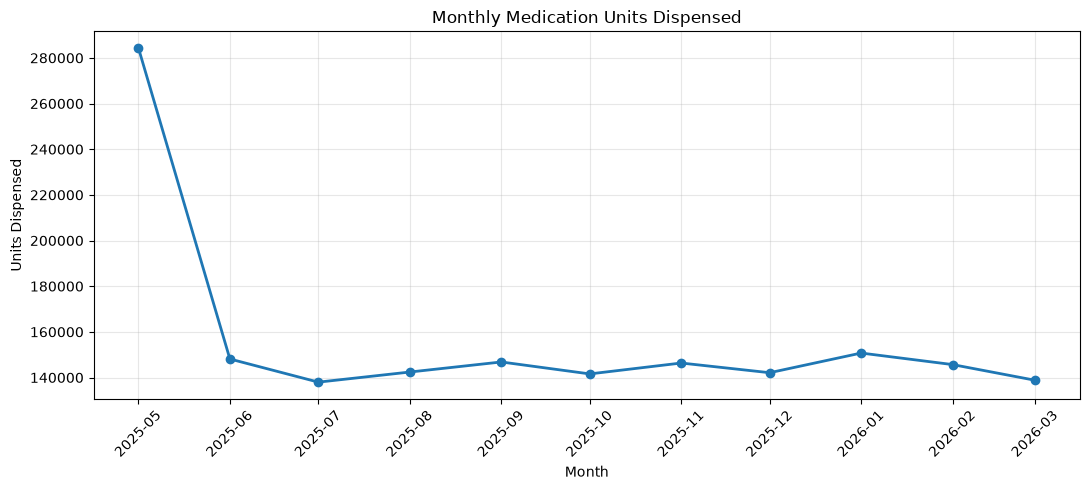

In [37]:
monthly_trend = (
    prescriptions_monthly
    .groupby("rx_month", as_index=False)
    .agg(
        total_prescriptions=("rx_count", "sum"),
        total_units_dispensed=("units_dispensed", "sum"),
        active_hcps=("hcp_id", "nunique"),
    )
    .sort_values("rx_month")
)

display(monthly_trend)

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_trend["rx_month"],
    monthly_trend["total_units_dispensed"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Medication Units Dispensed")
plt.xlabel("Month")
plt.ylabel("Units Dispensed")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,product_name,therapy_area,total_prescriptions,total_units_dispensed,prescribing_hcps,estimated_gross_value
1,Diabolite,Diabetes,8876,356130,431,135329400
0,Cardiozen,Cardiology,8606,346645,440,155990250
3,Oncoshield,Oncology,8799,346550,444,970340000
4,Neurofine,Neurology,8519,342384,437,212278080
2,Respira-X,Respiratory,8293,333128,439,173226560


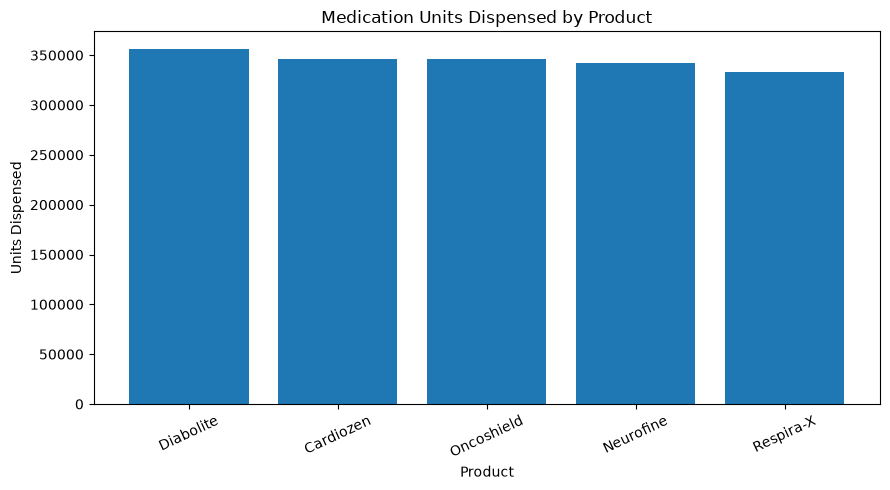

In [38]:
product_performance = (
    prescriptions_monthly
    .groupby("product_id", as_index=False)
    .agg(
        total_prescriptions=("rx_count", "sum"),
        total_units_dispensed=("units_dispensed", "sum"),
        prescribing_hcps=("hcp_id", "nunique"),
    )
    .merge(
        products[
            [
                "product_id",
                "product_name",
                "therapy_area",
                "unit_price",
            ]
        ],
        on="product_id",
        how="left",
        validate="one_to_one"
    )
)

product_performance["estimated_gross_value"] = (
    product_performance["total_units_dispensed"]
    * product_performance["unit_price"]
)

product_performance = product_performance.sort_values(
    "total_units_dispensed",
    ascending=False
)

display(
    product_performance[
        [
            "product_name",
            "therapy_area",
            "total_prescriptions",
            "total_units_dispensed",
            "prescribing_hcps",
            "estimated_gross_value",
        ]
    ]
)

plt.figure(figsize=(9, 5))

plt.bar(
    product_performance["product_name"],
    product_performance["total_units_dispensed"]
)

plt.title("Medication Units Dispensed by Product")
plt.xlabel("Product")
plt.ylabel("Units Dispensed")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

,call_type,total_calls,unique_hcps,average_duration_min,average_samples_given
0,F2F,10256,444,19.99,3.97
1,Virtual,3449,433,19.95,4.02


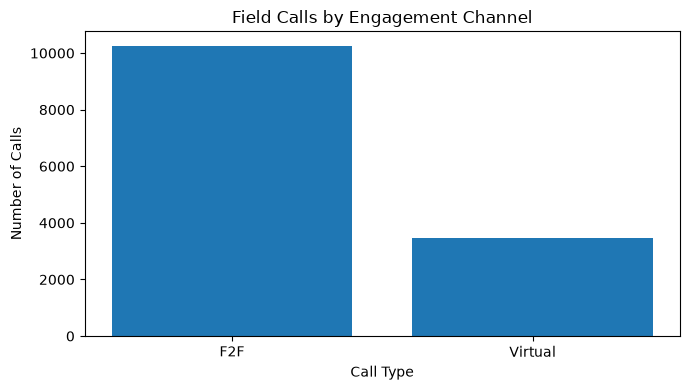

In [39]:
channel_summary = (
    calls
    .groupby("call_type", as_index=False)
    .agg(
        total_calls=("call_id", "count"),
        unique_hcps=("hcp_id", "nunique"),
        average_duration_min=("duration_min", "mean"),
        average_samples_given=("samples_given", "mean"),
    )
)

channel_summary[
    [
        "average_duration_min",
        "average_samples_given",
    ]
] = (
    channel_summary[
        [
            "average_duration_min",
            "average_samples_given",
        ]
    ]
    .round(2)
)

display(channel_summary)

plt.figure(figsize=(7, 4))

plt.bar(
    channel_summary["call_type"],
    channel_summary["total_calls"]
)

plt.title("Field Calls by Engagement Channel")
plt.xlabel("Call Type")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

Correlation between total calls and units dispensed: 0.599


,hcp_id,specialty,segment,total_calls,total_prescriptions,total_units_dispensed,prescriptions_per_call,days_since_last_call
322,H0323,Neurologist,B,73.00,354.00,"15,064.00",4.85,0.00
244,H0245,Cardiologist,A,34.00,337.00,"13,910.00",9.91,6.00
23,H0024,Cardiologist,B,73.00,373.00,"13,572.00",5.11,8.00
329,H0330,Pulmonologist,B,75.00,302.00,"11,944.00",4.03,2.00
142,H0143,Cardiologist,B,68.00,289.00,"11,853.00",4.25,0.00
132,H0133,General Physician,A,29.00,297.00,"11,596.00",10.24,6.00
68,H0069,Endocrinologist,A,27.00,266.00,"11,359.00",9.85,18.00
119,H0120,Cardiologist,B,64.00,294.00,"11,246.00",4.59,2.00
143,H0144,Endocrinologist,B,76.00,288.00,"10,910.00",3.79,6.00
6,H0007,Cardiologist,A,29.00,265.00,"10,562.00",9.14,26.00


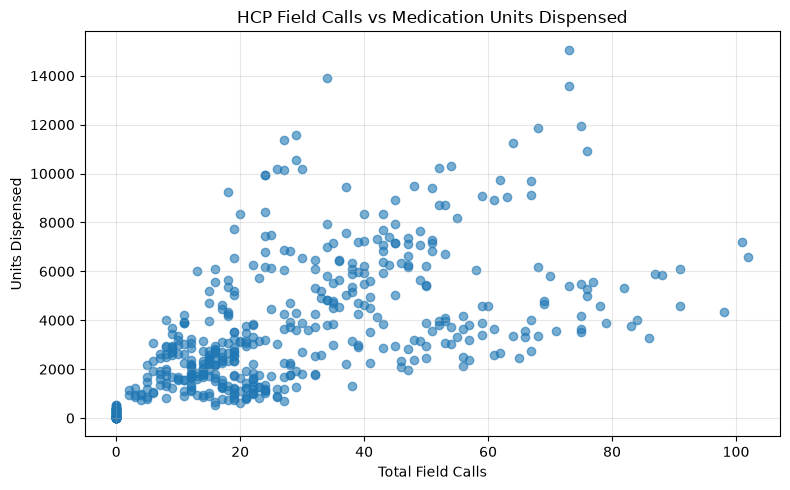

In [40]:
hcp_call_summary = (
    calls
    .groupby("hcp_id", as_index=False)
    .agg(
        total_calls=("call_id", "count"),
        average_call_duration=("duration_min", "mean"),
        total_samples_received=("samples_given", "sum"),
        last_call_date=("call_date", "max"),
    )
)

hcp_prescription_summary = (
    prescriptions_monthly
    .groupby("hcp_id", as_index=False)
    .agg(
        total_prescriptions=("rx_count", "sum"),
        total_units_dispensed=("units_dispensed", "sum"),
        product_breadth=("product_id", "nunique"),
    )
)

hcp_engagement = (
    hcps[
        [
            "hcp_id",
            "hcp_name",
            "specialty",
            "segment",
            "territory",
            "region",
        ]
    ]
    .merge(
        hcp_call_summary,
        on="hcp_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        hcp_prescription_summary,
        on="hcp_id",
        how="left",
        validate="one_to_one"
    )
)

numeric_columns = [
    "total_calls",
    "average_call_duration",
    "total_samples_received",
    "total_prescriptions",
    "total_units_dispensed",
    "product_breadth",
]

hcp_engagement[numeric_columns] = (
    hcp_engagement[numeric_columns].fillna(0)
)

REFERENCE_DATE = calls["call_date"].max().normalize()

hcp_engagement["days_since_last_call"] = (
    REFERENCE_DATE - hcp_engagement["last_call_date"]
).dt.days

hcp_engagement["prescriptions_per_call"] = np.where(
    hcp_engagement["total_calls"] > 0,
    (
        hcp_engagement["total_prescriptions"]
        / hcp_engagement["total_calls"]
    ),
    np.nan
)

hcp_engagement["prescriptions_per_call"] = (
    hcp_engagement["prescriptions_per_call"].round(2)
)

call_prescription_correlation = (
    hcp_engagement[
        [
            "total_calls",
            "total_units_dispensed",
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Correlation between total calls and units dispensed:",
    round(call_prescription_correlation, 3)
)

display(
    hcp_engagement[
        [
            "hcp_id",
            "specialty",
            "segment",
            "total_calls",
            "total_prescriptions",
            "total_units_dispensed",
            "prescriptions_per_call",
            "days_since_last_call",
        ]
    ]
    .sort_values(
        "total_units_dispensed",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(8, 5))

plt.scatter(
    hcp_engagement["total_calls"],
    hcp_engagement["total_units_dispensed"],
    alpha=0.6
)

plt.title("HCP Field Calls vs Medication Units Dispensed")
plt.xlabel("Total Field Calls")
plt.ylabel("Units Dispensed")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,territory,region,total_calls,covered_hcps,total_samples,total_prescriptions,total_units_dispensed,prescribing_hcps,units_per_call
1,Central-2,Central,660.00,49.00,"2,652.00",2245,91941,49,139.30
5,North-2,North,"2,583.00",57.00,"10,315.00",8642,348582,57,134.95
7,South-2,South,"2,840.00",48.00,"11,278.00",9627,381432,48,134.31
9,West-2,West,947.00,59.00,"3,650.00",3115,123939,59,130.88
4,North-1,North,"1,459.00",34.00,"5,824.00",4522,183480,34,125.76
3,East-2,East,785.00,53.00,"3,137.00",2433,98312,53,125.24
8,West-1,West,986.00,54.00,"3,949.00",2813,113251,54,114.86
6,South-1,South,"1,479.00",44.00,"5,889.00",4300,169846,44,114.84
0,Central-1,Central,"1,966.00",46.00,"7,863.00",5157,204518,46,104.03
2,East-1,East,0.00,0.00,0.00,239,9536,41,NaN


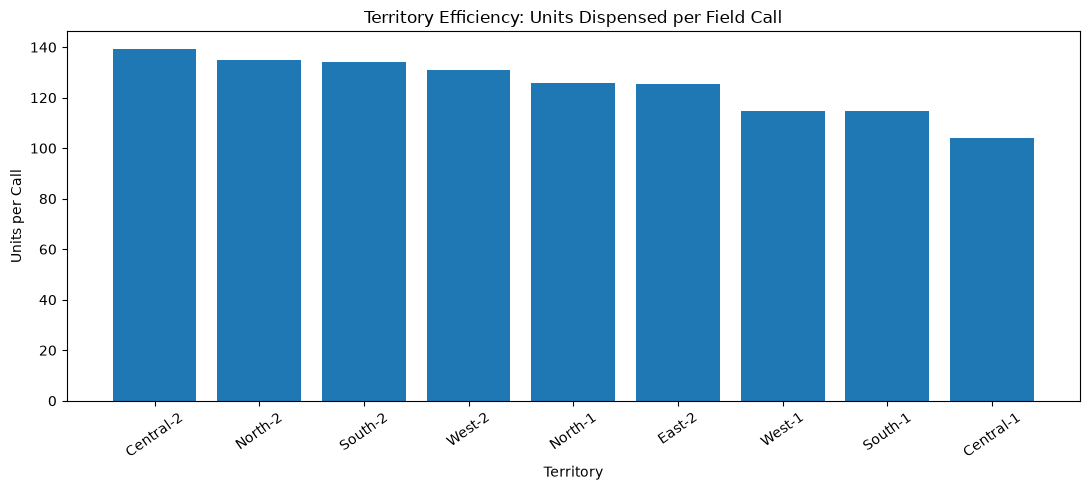

In [41]:
hcp_location = hcps[
    [
        "hcp_id",
        "territory",
        "region",
    ]
]

territory_calls = (
    calls
    .merge(
        hcp_location,
        on="hcp_id",
        how="left",
        validate="many_to_one"
    )
    .groupby(
        ["territory", "region"],
        as_index=False
    )
    .agg(
        total_calls=("call_id", "count"),
        covered_hcps=("hcp_id", "nunique"),
        total_samples=("samples_given", "sum"),
    )
)

territory_prescriptions = (
    prescriptions_monthly
    .merge(
        hcp_location,
        on="hcp_id",
        how="left",
        validate="many_to_one"
    )
    .groupby(
        ["territory", "region"],
        as_index=False
    )
    .agg(
        total_prescriptions=("rx_count", "sum"),
        total_units_dispensed=("units_dispensed", "sum"),
        prescribing_hcps=("hcp_id", "nunique"),
    )
)

territory_performance = (
    territory_calls
    .merge(
        territory_prescriptions,
        on=["territory", "region"],
        how="outer"
    )
)

territory_numeric_columns = [
    "total_calls",
    "covered_hcps",
    "total_samples",
    "total_prescriptions",
    "total_units_dispensed",
    "prescribing_hcps",
]

territory_performance[territory_numeric_columns] = (
    territory_performance[
        territory_numeric_columns
    ]
    .fillna(0)
)

territory_performance["units_per_call"] = np.where(
    territory_performance["total_calls"] > 0,
    (
        territory_performance["total_units_dispensed"]
        / territory_performance["total_calls"]
    ),
    np.nan
)

territory_performance["units_per_call"] = (
    territory_performance["units_per_call"].round(2)
)

territory_performance = territory_performance.sort_values(
    "units_per_call",
    ascending=False
)

display(territory_performance)

plt.figure(figsize=(11, 5))

plt.bar(
    territory_performance["territory"],
    territory_performance["units_per_call"]
)

plt.title("Territory Efficiency: Units Dispensed per Field Call")
plt.xlabel("Territory")
plt.ylabel("Units per Call")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [42]:
hcp_engagement.to_csv(
    OUTPUT_DIR / "hcp_engagement_summary.csv",
    index=False,
    date_format="%Y-%m-%d"
)

territory_performance.to_csv(
    OUTPUT_DIR / "territory_performance_summary.csv",
    index=False
)

product_performance.to_csv(
    OUTPUT_DIR / "product_performance_summary.csv",
    index=False
)

print("Focused EDA summary tables exported successfully.")

Focused EDA summary tables exported successfully.


In [43]:
duplicate_concentration = (
    prescriptions_monthly
    .groupby("rx_month", as_index=False)
    .agg(
        monthly_rows=("monthly_prescription_id", "count"),
        multi_source_rows=(
            "source_record_count",
            lambda values: (values > 1).sum()
        ),
        total_source_records=("source_record_count", "sum"),
        maximum_source_records=("source_record_count", "max"),
    )
)

duplicate_concentration["multi_source_percentage"] = (
    duplicate_concentration["multi_source_rows"]
    .div(duplicate_concentration["monthly_rows"])
    .mul(100)
    .round(2)
)

display(duplicate_concentration)

,rx_month,monthly_rows,multi_source_rows,total_source_records,maximum_source_records,multi_source_percentage
0,2025-05-01,1784,1093,2877,2,61.27
1,2025-06-01,1449,0,1449,1,0.00
2,2025-07-01,1390,0,1390,1,0.00
3,2025-08-01,1453,0,1453,1,0.00
4,2025-09-01,1469,0,1469,1,0.00
5,2025-10-01,1441,0,1441,1,0.00
6,2025-11-01,1451,0,1451,1,0.00
7,2025-12-01,1454,0,1454,1,0.00
8,2026-01-01,1468,0,1468,1,0.00
9,2026-02-01,1445,0,1445,1,0.00


In [44]:
east_1_hcps = hcps[
    hcps["territory"] == "East-1"
]

east_1_reps = sales_reps[
    sales_reps["territory"] == "East-1"
]

east_1_calls = (
    calls
    .merge(
        hcps[["hcp_id", "territory"]],
        on="hcp_id",
        how="left",
        validate="many_to_one"
    )
    .query("territory == 'East-1'")
)

east_1_summary = pd.DataFrame(
    {
        "metric": [
            "HCPs assigned to East-1",
            "Sales reps assigned to East-1",
            "Calls made to East-1 HCPs",
            "East-1 HCPs receiving at least one call",
        ],
        "value": [
            east_1_hcps["hcp_id"].nunique(),
            east_1_reps["rep_id"].nunique(),
            len(east_1_calls),
            east_1_calls["hcp_id"].nunique(),
        ],
    }
)

display(east_1_summary)
display(east_1_reps)

,metric,value
0,HCPs assigned to East-1,56
1,Sales reps assigned to East-1,0
2,Calls made to East-1 HCPs,0
3,East-1 HCPs receiving at least one call,0


,rep_id,rep_name,territory,region,manager,tenure_months,hire_date


In [46]:
# Use a consistent analysis period.
# May 2025 is excluded because repeated source records
# are concentrated only in that month.

ANALYSIS_START_DATE = pd.Timestamp("2025-06-01")

analysis_prescriptions_monthly = (
    prescriptions_monthly.loc[
        prescriptions_monthly["rx_month"]
        >= ANALYSIS_START_DATE
    ]
    .copy()
)

print(
    "Analysis period:",
    analysis_prescriptions_monthly["rx_month"].min().date(),
    "to",
    analysis_prescriptions_monthly["rx_month"].max().date()
)

print(
    "Rows used for analysis:",
    f"{len(analysis_prescriptions_monthly):,}"
)

Analysis period: 2025-06-01 to 2026-03-01
Rows used for analysis: 14,452


In [47]:
analysis_prescriptions_monthly.to_csv(
    PROCESSED_DATA_DIR
    / "analysis_monthly_prescriptions.csv",
    index=False,
    date_format="%Y-%m-%d"
)

print("Analysis prescription table exported successfully.")

Analysis prescription table exported successfully.


## Key EDA Findings

- Monthly medication volume remained relatively stable from June 2025 to March 2026, generally ranging between approximately 138,000 and 151,000 units.
- May 2025 contained repeated source records for 61.27% of its HCP-product combinations. It was retained for auditability but excluded from comparative trends and machine-learning feature creation.
- Diabolite generated the highest medication volume, while Oncoshield produced the highest estimated gross value because of its significantly higher unit price.
- Face-to-face interactions represented approximately 75% of all field calls. Face-to-face and virtual calls had nearly identical average durations and sample distributions.
- Field-call volume and medication units dispensed showed a moderate positive correlation of **0.599**. This suggests that engagement is associated with prescription activity, but call frequency alone does not explain HCP performance.
- HCPs showed substantial variation in prescriptions per call, indicating that field-call volume alone does not explain prescription performance.
- Central-2 recorded the highest medication units per call among territories with active field coverage.
- East-1 contained 56 HCPs and 41 prescribing HCPs but had no assigned sales representative or field calls, representing a clear field-coverage opportunity.
- These findings support the use of prescription value, growth, engagement frequency, call efficiency, product breadth, and recency as features for HCP segmentation.
